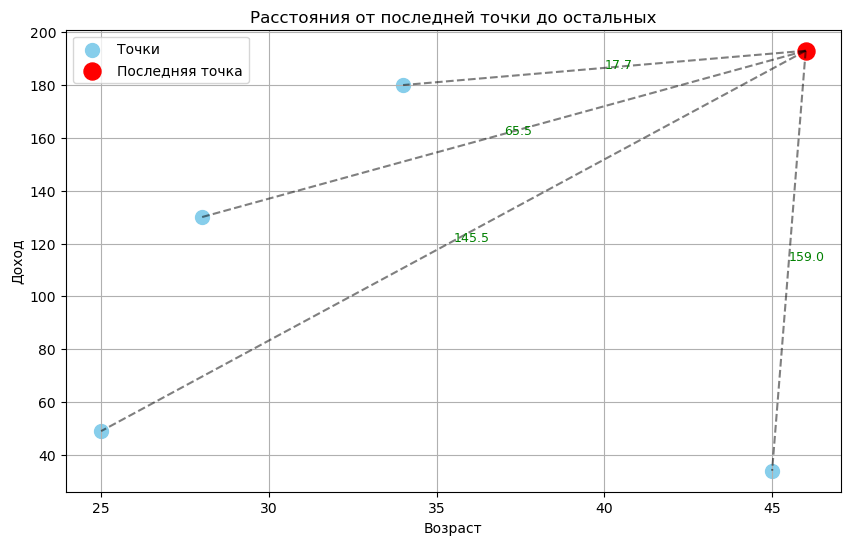

In [23]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np          

df = pd.DataFrame({
    'возраст': [25,45,34,28,46],
    'доход': [49,34,180,130,193],
    'default': [1,1,0,0,0]},
    index = [0,1,2,3,4])
df

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.33)
X_train.shape,X_test.shape,y_train.shape,y_test.shape
X_train.head()
y_train.head()
model = KNeighborsClassifier(n_neighbors = 3)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_pred
center = df.iloc[-1][['возраст', 'доход']]

# Построим график
plt.figure(figsize=(10, 6))

# Нарисуем все точки
plt.scatter(df['возраст'], df['доход'], c='skyblue', s=100, label='Точки')
plt.scatter(center['возраст'], center['доход'], c='red', s=150, label='Последняя точка')

# Подпишем расстояния от последней точки до всех остальных
for i in range(len(df) - 1):  # не включаем последнюю точку
    x1, y1 = center['возраст'], center['доход']
    x2, y2 = df.loc[i, 'возраст'], df.loc[i, 'доход']
    
    distance = np.linalg.norm([x1 - x2, y1 - y2])
    
    # Линия
    plt.plot([x1, x2], [y1, y2], 'k--', alpha=0.5)
    
    # Подпись расстояния
    mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
    plt.text(mid_x, mid_y, f"{distance:.1f}", fontsize=9, color='green')

plt.xlabel('Возраст')
plt.ylabel('Доход')
plt.title('Расстояния от последней точки до остальных')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_9200\1024339186.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Dataset.loc[:, 'person_gender'] = Dataset['person_gender'].replace(replace_gender)
C:\Users\user\AppData\Local\Temp\ipykernel_9200\1024339186.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Dataset.loc[:, 'person_education'] = Dataset['person_education'].replace(replace_education)
C:\Users\user\AppData\Local\Temp\ipykernel_9200\1024339186.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will

Точность: 83 %
F1 score 54 %
F2 score 52 %
Матрица ошибок:
 [[8591  501]
 [1435 1167]]


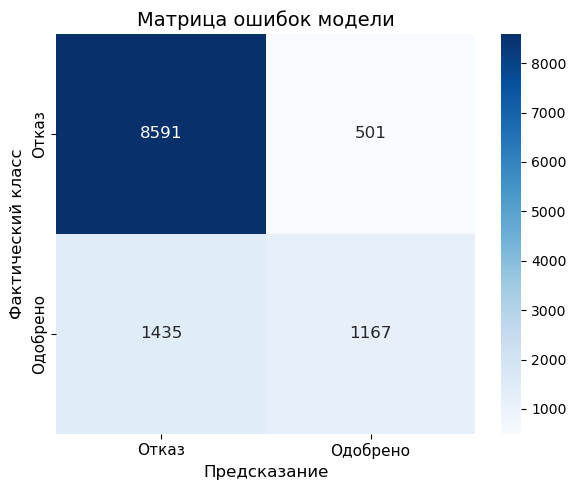

In [1]:

import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, fbeta_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  
df = pd.read_csv('F:/датасеты/bank_loans_credit.csv')
need_colomuns = ['person_age','person_gender','person_education','person_income','person_emp_exp',
                 'person_home_ownership', 'loan_amnt','loan_status']
Dataset = df[need_colomuns]
Dataset.describe()
replace_gender = {
    'female':0,
    'male':1,
}
replace_education = {
    'Master':1,
    'Bachelor':2,
    'High School':3,
    'College':4,
        'Associate':5,
    'Doctorate':6
}
replace_person_home_ownership = {
    'RENT':0,
    'OWN':1,
    'MORTGAGE':2,
    'OTHER':3

}
Dataset.loc[:, 'person_gender'] = Dataset['person_gender'].replace(replace_gender)
Dataset.loc[:, 'person_education'] = Dataset['person_education'].replace(replace_education)
Dataset.loc[:, 'person_home_ownership'] = Dataset['person_home_ownership'].replace(replace_person_home_ownership)
def remove_outliers_iqr(data, threshold=1.5):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]
for column in need_colomuns[:-1]:  
    Dataset[column] = remove_outliers_iqr(Dataset[column])
Dataset = Dataset.dropna()
Dataset = Dataset.drop_duplicates()
minimax_scaler = MinMaxScaler()
Z_scaler = StandardScaler()
Dataset['person_age'] = minimax_scaler.fit_transform(Dataset[['person_age']])
Dataset['person_income'] = Z_scaler.fit_transform(Dataset[['person_income']])
Dataset['loan_amnt'] = Z_scaler.fit_transform(Dataset[['loan_amnt']])
Dataset['person_education'] = minimax_scaler.fit_transform(Dataset[['person_education']])
Dataset['person_emp_exp'] = minimax_scaler.fit_transform(Dataset[['person_emp_exp']])
Dataset['person_home_ownership'] = minimax_scaler.fit_transform(Dataset[['person_home_ownership']])
X_train, X_test, y_train, y_test = train_test_split(Dataset.iloc[:,:-1], Dataset.iloc[:,-1], test_size=0.3)
model = KNeighborsClassifier(n_neighbors = 5, weights='distance')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)
threshold = 0.4
y_pred_custom = (probs[:, 1] >= threshold).astype(int)
accuracy = model.score(X_test, y_test)
print("Точность:", round(accuracy * 100), '%')
print("F1 score", round((f1_score(y_test, y_pred_custom)) * 100),'%')
print("F2 score", round((fbeta_score(y_test, y_pred_custom, beta=2)) * 100),'%')
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:\n", cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Отказ", "Одобрено"],
            yticklabels=["Отказ", "Одобрено"],
            annot_kws={"fontsize": 12})
plt.xlabel('Предсказание', fontsize=12)
plt.ylabel('Фактический класс', fontsize=12)
plt.title('Матрица ошибок модели', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


X_train shape: (27284, 7)
X_test shape: (11694, 7)
y_train shape: (27284,)
y_test shape: (11694,)
Предсказания: [0 0 0 ... 0 0 0]
Точность: 84 %
F1 score 54 %
F2 score 52 %
Матрица ошибок:
 [[8601  495]
 [1410 1188]]


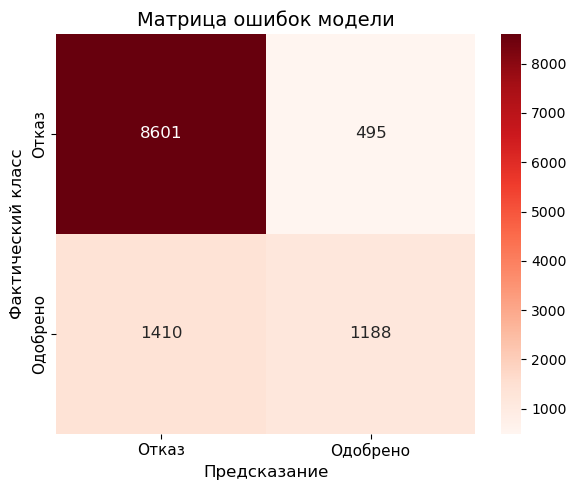

In [45]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, fbeta_score
import numpy as np  

#загрузка датасета
df = pd.read_csv('F:/датасеты/bank_loans_credit.csv')
need_colomuns = ['person_age','person_gender','person_education','person_income','person_emp_exp','person_home_ownership', 'loan_amnt','loan_status']
Dataset = df[need_colomuns]


# Преобразование категориальных переменных в числовые
replace_gender = {
    'female':0,
    'male':1,
}
replace_education = {
    'Master':1,
    'Bachelor':2,
    'High School':3,
    'College':4,
    'Associate':5,
    'Doctorate':6
}
replace_person_home_ownership = {
    'RENT':0,
    'OWN':1,
    'MORTGAGE':2,
    'OTHER':3

}
Dataset.loc[:, 'person_gender'] = Dataset['person_gender'].replace(replace_gender)
Dataset.loc[:, 'person_education'] = Dataset['person_education'].replace(replace_education)
Dataset.loc[:, 'person_home_ownership'] = Dataset['person_home_ownership'].replace(replace_person_home_ownership)

# удаление выбросов
def remove_outliers_iqr(data, threshold=1.5):
    #вычисление середины в Q1 и Q3
    Q1 = np.percentile(data, 25) 
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]
# Удаление выбросов
for column in need_colomuns[:-1]:  # Исключаем последний столбец (целевую переменную)
    Dataset[column] = remove_outliers_iqr(Dataset[column])
# Удаление строк с NaN
Dataset = Dataset.dropna()
Dataset = Dataset.drop_duplicates()
# Нормализация переменных с помощью MinMaxScaler и StandardScaler
minimax_scaler = MinMaxScaler()
Z_scaler = StandardScaler()
Dataset['person_age'] = minimax_scaler.fit_transform(Dataset[['person_age']])
Dataset['person_income'] = Z_scaler.fit_transform(Dataset[['person_income']])
Dataset['loan_amnt'] = Z_scaler.fit_transform(Dataset[['loan_amnt']])
Dataset['person_education'] = minimax_scaler.fit_transform(Dataset[['person_education']])
Dataset['person_emp_exp'] = minimax_scaler.fit_transform(Dataset[['person_emp_exp']])
Dataset['person_home_ownership'] = minimax_scaler.fit_transform(Dataset[['person_home_ownership']])

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(Dataset.iloc[:,:-1], Dataset.iloc[:,-1], test_size=0.3)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

model = KNeighborsClassifier(n_neighbors = 5, weights='distance')
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("Предсказания:", y_pred)

probs = model.predict_proba(X_test)
threshold = 0.4
y_pred_custom = (probs[:, 1] >= threshold).astype(int)

# Вывод точности модели
accuracy = model.score(X_test, y_test)
print("Точность:", round(accuracy * 100), '%')
print("F1 score", round((f1_score(y_test, y_pred_custom)) * 100),'%')
print("F2 score", round((fbeta_score(y_test, y_pred_custom, beta=2)) * 100),'%')
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=["Отказ", "Одобрено"],
            yticklabels=["Отказ", "Одобрено"],
            annot_kws={"fontsize": 12})
plt.xlabel('Предсказание', fontsize=12)
plt.ylabel('Фактический класс', fontsize=12)
plt.title('Матрица ошибок модели', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, fbeta_score
import numpy as np  

df = pd.read_csv('F:/датасеты/bank_loans_credit.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
